In [1]:
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/qinglizeng1997/uavids-2025/UAVIDS-2025.csv


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/qinglizeng1997/uavids-2025/UAVIDS-2025.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nDtypes:\n", df.dtypes)
print("\nHead:")
df.head()

Shape: (122171, 23)

Columns: ['FlowID', 'FlowDuration/s', 'SrcAddr', 'SrcPort', 'DstAddr', 'DstPort', 'Protocol', 'TxPackets', 'RxPackets', 'LostPackets', 'TxBytes', 'RxBytes', 'TxPacketRate/s', 'RxPacketRate/s', 'TxByteRate/s', 'RxByteRate/s', 'MeanDelay/s', 'MeanJitter/s', 'Throughput/Kbps', 'MeanPacketSize', 'PacketDropRate', 'AverageHopCount', 'label']

Dtypes:
 FlowID               int64
FlowDuration/s     float64
SrcAddr             object
SrcPort              int64
DstAddr             object
DstPort              int64
Protocol            object
TxPackets            int64
RxPackets            int64
LostPackets          int64
TxBytes              int64
RxBytes              int64
TxPacketRate/s     float64
RxPacketRate/s     float64
TxByteRate/s       float64
RxByteRate/s       float64
MeanDelay/s        float64
MeanJitter/s       float64
Throughput/Kbps    float64
MeanPacketSize       int64
PacketDropRate     float64
AverageHopCount    float64
label               object
dtype: ob

,FlowID,FlowDuration/s,SrcAddr,SrcPort,DstAddr,DstPort,Protocol,TxPackets,RxPackets,LostPackets,...,RxPacketRate/s,TxByteRate/s,RxByteRate/s,MeanDelay/s,MeanJitter/s,Throughput/Kbps,MeanPacketSize,PacketDropRate,AverageHopCount,label
0,1,175.007,192.168.0.150,9,192.168.0.16,9,UDP,251,215,36,...,1.22853,109.002,93.3679,0.022152,0.024406,0.746943,76,0.143426,0.074419,Sybil Attack
1,2,175.008,192.168.0.150,9,192.168.0.19,9,UDP,251,223,28,...,1.27423,109.001,96.8411,0.019637,0.018678,0.774729,76,0.111554,0.053812,Sybil Attack
2,3,175.010,192.168.0.150,9,192.168.0.24,9,UDP,251,224,27,...,1.27993,108.999,97.2744,0.023701,0.023917,0.778195,76,0.107570,0.044643,Sybil Attack
3,4,175.014,192.168.0.150,9,192.168.0.34,9,UDP,251,212,39,...,1.21133,108.997,92.0614,0.034014,0.025408,0.736491,76,0.155378,0.033019,Sybil Attack
4,5,175.017,192.168.0.150,9,192.168.0.39,9,UDP,251,215,36,...,1.22845,108.995,93.3623,0.034396,0.024933,0.746899,76,0.143426,0.009302,Sybil Attack


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# =====================
# 1) توزيع الفئات
# =====================
print("=== Class distribution ===")
print(df['label'].value_counts())
print("\n=== Class distribution (%) ===")
print((df['label'].value_counts(normalize=True) * 100).round(2))

# =====================
# 2) معالجة سريعة
# =====================
data = df.copy()

# احذفي معرّف التدفّق (ما يفيد التعلم)
data = data.drop(columns=['FlowID'])

# رمّزي الأعمدة الفئوية
cat_cols = ['SrcAddr', 'DstAddr', 'Protocol']
for col in cat_cols:
    data[col] = LabelEncoder().fit_transform(data[col].astype(str))

# رمّزي الـ label
le_y = LabelEncoder()
y = le_y.fit_transform(data['label'].astype(str))
X = data.drop(columns=['label']).values
feature_names = data.drop(columns=['label']).columns.tolist()

print(f"\nClasses encoded as: {dict(zip(le_y.classes_, range(len(le_y.classes_))))}")
print(f"X shape: {X.shape} | y shape: {y.shape}")

# =====================
# 3) Stratified split
# =====================
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain: {X_tr.shape} | Test: {X_te.shape}")

# =====================
# 4) RF Baseline
# =====================
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)

# =====================
# 5) النتائج
# =====================
print("\n=== Classification Report ===")
print(classification_report(y_te, y_pred, target_names=le_y.classes_, zero_division=0))

print("=== Confusion Matrix ===")
print("Rows = True, Cols = Predicted")
print("Order:", list(le_y.classes_))
print(confusion_matrix(y_te, y_pred))

# =====================
# 6) أهم الفيتشرز
# =====================
print("\n=== Top 10 Features ===")
imp = sorted(zip(feature_names, rf.feature_importances_), key=lambda t: -t[1])
for n, v in imp[:10]:
    print(f"{n:25s} {v:.4f}")

=== Class distribution ===
label
Normal Traffic      26172
Blackhole Attack    26110
Wormhole Attack     26086
Sybil Attack        24077
Flooding Attack     19726
Name: count, dtype: int64

=== Class distribution (%) ===
label
Normal Traffic      21.42
Blackhole Attack    21.37
Wormhole Attack     21.35
Sybil Attack        19.71
Flooding Attack     16.15
Name: proportion, dtype: float64

Classes encoded as: {'Blackhole Attack': 0, 'Flooding Attack': 1, 'Normal Traffic': 2, 'Sybil Attack': 3, 'Wormhole Attack': 4}
X shape: (122171, 21) | y shape: (122171,)

Train: (97736, 21) | Test: (24435, 21)

=== Classification Report ===
                  precision    recall  f1-score   support

Blackhole Attack       0.95      0.87      0.91      5222
 Flooding Attack       1.00      1.00      1.00      3945
  Normal Traffic       0.99      0.99      0.99      5235
    Sybil Attack       1.00      1.00      1.00      4816
 Wormhole Attack       0.87      0.95      0.91      5217

        accuracy 

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

# =====================
# 1) Preprocessing
# =====================
data = df.copy()

# رتّبي بـ FlowID للحفاظ على ترتيب التدفّق الزمني
data = data.sort_values('FlowID').reset_index(drop=True)
data = data.drop(columns=['FlowID'])

# رمّزي الأعمدة الفئوية
for col in ['SrcAddr', 'DstAddr', 'Protocol']:
    data[col] = LabelEncoder().fit_transform(data[col].astype(str))

# رمّزي الـ label
le_y = LabelEncoder()
y_all = le_y.fit_transform(data['label'].astype(str)).astype(np.int64)
X_all = data.drop(columns=['label']).values.astype(np.float32)
feature_names = data.drop(columns=['label']).columns.tolist()

num_classes = len(le_y.classes_)
print(f"Classes: {dict(zip(le_y.classes_, range(num_classes)))}")
print(f"X: {X_all.shape}  y: {y_all.shape}")

# =====================
# 2) ابني السلاسل من البيانات المرتّبة
# =====================
seq_len = 10
Xs, ys = [], []
for i in range(len(X_all) - seq_len):
    Xs.append(X_all[i:i+seq_len])
    ys.append(y_all[i+seq_len])
Xs = np.asarray(Xs, dtype=np.float32)
ys = np.asarray(ys, dtype=np.int64)
print(f"Sequences: {Xs.shape}")

# =====================
# 3) Stratified split على السلاسل
# =====================
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    Xs, ys, test_size=0.30, random_state=42, stratify=ys)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)
print(f"Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_te.shape}")

# =====================
# 4) Scaling: fit على train فقط
# =====================
scaler = StandardScaler().fit(X_tr.reshape(-1, X_tr.shape[2]))
def sc(X3):
    s = X3.shape
    return scaler.transform(X3.reshape(-1, s[2])).reshape(s).astype(np.float32)
X_tr_s, X_val_s, X_te_s = sc(X_tr), sc(X_val), sc(X_te)

# =====================
# 5) Tensors
# =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

X_tr_t  = torch.tensor(X_tr_s).to(device);  y_tr_t  = torch.tensor(y_tr).to(device)
X_val_t = torch.tensor(X_val_s).to(device); y_val_t = torch.tensor(y_val).to(device)
X_te_t  = torch.tensor(X_te_s).to(device);  y_te_t  = torch.tensor(y_te).to(device)

# =====================
# 6) النموذج الهجين: LNN (آخر خطوة) + BiLSTM (السلسلة كاملة)
# =====================
class HybridIDS(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        # LNN: شبكة خفيفة لكشف الشذوذ اللحظي
        self.lnn = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(0.2),
        )
        # LSTM: شبكة زمنية لكشف الأنماط المتطورة
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=64,
            num_layers=2, batch_first=True,
            dropout=0.3, bidirectional=True,
        )
        # دمج (Score Fusion)
        self.fc = nn.Sequential(
            nn.Linear(64 + 128, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        a = self.lnn(x[:, -1, :])                  # (B, 64)
        b, _ = self.lstm(x); b = b[:, -1, :]       # (B, 128)
        return self.fc(torch.cat((a, b), dim=1))   # (B, num_classes)

model = HybridIDS(X_tr_s.shape[2], num_classes).to(device)
print(model)

# =====================
# 7) التدريب
# =====================
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

epochs, batch_size, patience = 40, 128, 6
best_val, bad, best_state = float('inf'), 0, None

for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_tr_t.size(0))
    tot = 0.0
    for i in range(0, X_tr_t.size(0), batch_size):
        idx = perm[i:i+batch_size]
        optimizer.zero_grad()
        loss = criterion(model(X_tr_t[idx]), y_tr_t[idx])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tot += loss.item() * idx.size(0)
    tr_loss = tot / X_tr_t.size(0)

    model.eval()
    with torch.no_grad():
        v_loss = criterion(model(X_val_t), y_val_t).item()
    scheduler.step(v_loss)
    print(f"Epoch {epoch+1:02d}/{epochs} | train {tr_loss:.4f} | val {v_loss:.4f}")

    if v_loss < best_val - 1e-6:
        best_val, bad = v_loss, 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        bad += 1
        if bad >= patience:
            print("Early stopping."); break

model.load_state_dict(best_state)

# =====================
# 8) التقييم النهائي
# =====================
model.eval()
with torch.no_grad():
    t0 = time.time(); logits = model(X_te_t); t1 = time.time()

y_pred = torch.argmax(logits, dim=1).cpu().numpy()
y_true = y_te_t.cpu().numpy()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
inf_ms = ((t1 - t0) / len(X_te_t)) * 1000

print("\n=== Final Results (Macro-averaged) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"Inference/sample: {inf_ms:.4f} ms")

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=le_y.classes_, zero_division=0))

print("=== Confusion Matrix ===")
print("Order:", list(le_y.classes_))
print(confusion_matrix(y_true, y_pred))

Classes: {'Blackhole Attack': 0, 'Flooding Attack': 1, 'Normal Traffic': 2, 'Sybil Attack': 3, 'Wormhole Attack': 4}
X: (122171, 21)  y: (122171,)
Sequences: (122161, 10, 21)
Train: (85512, 10, 21) | Val: (18324, 10, 21) | Test: (18325, 10, 21)
Device: cpu
HybridIDS(
  (lnn): Sequential(
    (0): Linear(in_features=21, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
  )
  (lstm): LSTM(21, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=192, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=5, bias=True)
  )
)
Epoch 01/40 | train 0.4251 | val 0.2321
Epoch 02/40 | train 0.2271 | val 0.2023
Epoch 03/40 | train 0.2051 | val 0.1941
Epoch 04/40 | train 0.1923 | val 0.1957
Epoch 05/40 | train 0.18

Swarm size      : 10
Honest UAVs     : [2, 3, 4, 6, 7, 9]
Compromised UAVs: [np.int64(0), np.int64(1), np.int64(5), np.int64(8)] (colluding → vote 'Normal Traffic')

=== Per-UAV Scores ===
 UAV          Type    Trust  Collusion   Weight
   0   compromised   0.2664     1.0000   0.0000
   1   compromised   0.2664     1.0000   0.0000
   2        honest   0.7568     0.0000   0.7568
   3        honest   0.7563     0.0000   0.7563
   4        honest   0.7562     0.0000   0.7562
   5   compromised   0.2664     1.0000   0.0000
   6        honest   0.7599     0.0000   0.7599
   7        honest   0.7609     0.0000   0.7609
   8   compromised   0.2664     1.0000   0.0000
   9        honest   0.7535     0.0000   0.7535

Strategy                                           Acc     Prec      Rec       F1
Single Model (no voting)                        0.9356   0.9430   0.9398   0.9392
Simple Majority Voting                          0.8635   0.9058   0.8682   0.8765
Trust-weighted Voting               

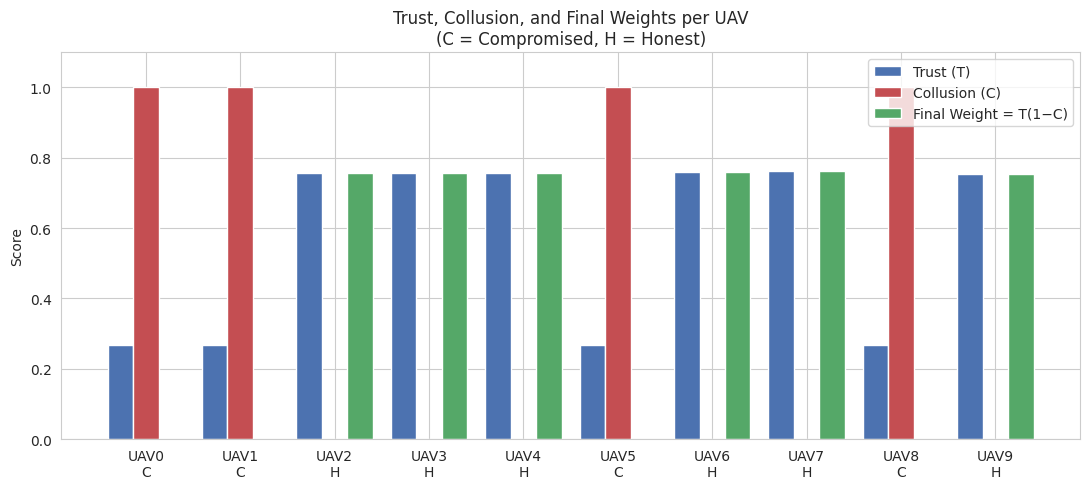

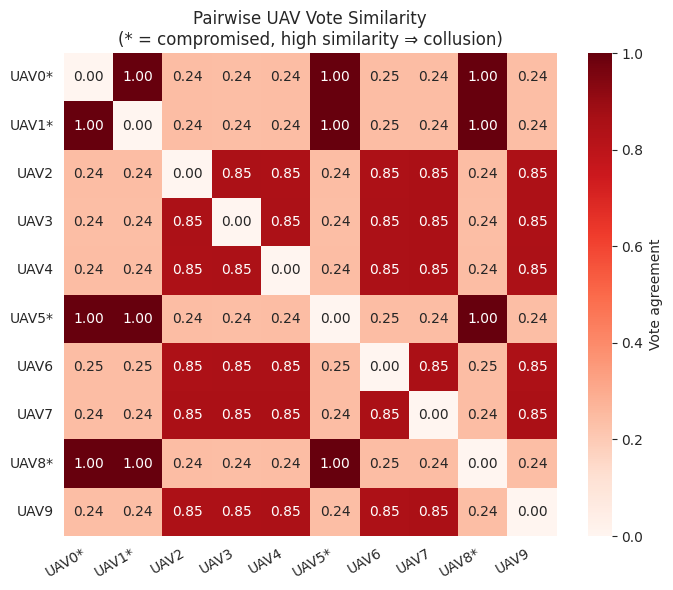

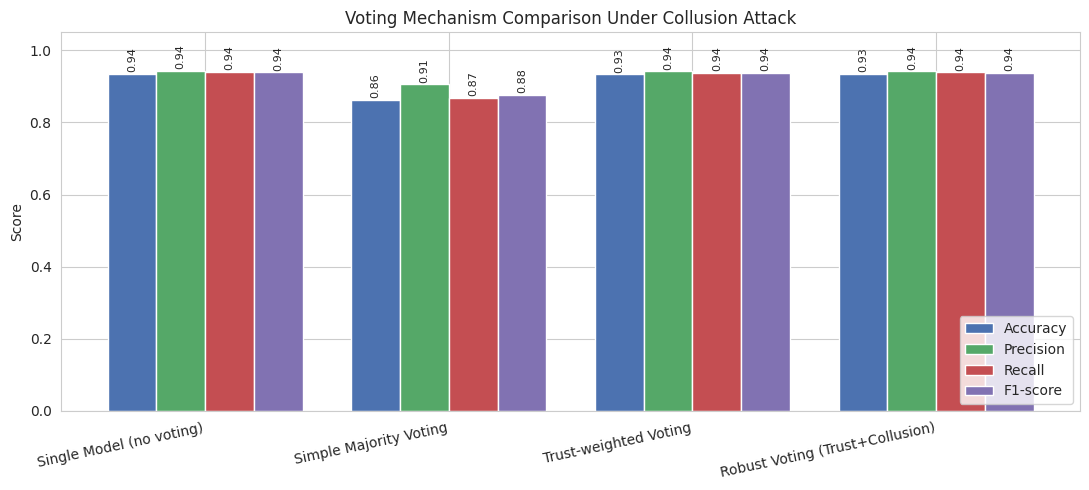


Saved: uav_scores.png, similarity_matrix.png, voting_comparison.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

sns.set_style("whitegrid")

# =====================
# 1) خرّجي احتمالات النموذج لمجموعة الاختبار
# =====================
model.eval()
with torch.no_grad():
    test_logits = model(X_te_t)
    test_probs  = torch.softmax(test_logits, dim=1).cpu().numpy()    # (N, 5)
    test_preds  = test_probs.argmax(axis=1)
y_true_test = y_te_t.cpu().numpy()
N = len(test_preds)

# =====================
# 2) إعداد السرب — Simulated Multi-UAV Environment
# =====================
np.random.seed(42)

NUM_UAVS         = 10                            # عدد العقد في السرب
NUM_COMPROMISED  = 4                             # عقد مخترقة متواطئة
COLLUSION_TARGET = 2                             # كل المتواطئين يصوّتون: Normal Traffic
HONEST_NOISE     = 0.10                          # 10% ضوضاء على العقدة الشريفة

uav_ids = list(range(NUM_UAVS))
compromised_uavs = set(np.random.choice(uav_ids, NUM_COMPROMISED, replace=False))
honest_uavs      = [u for u in uav_ids if u not in compromised_uavs]

print(f"Swarm size      : {NUM_UAVS}")
print(f"Honest UAVs     : {sorted(honest_uavs)}")
print(f"Compromised UAVs: {sorted(compromised_uavs)} (colluding → vote '{le_y.classes_[COLLUSION_TARGET]}')")

# =====================
# 3) محاكاة تصويت كل UAV على كل flow
# =====================
votes = np.zeros((NUM_UAVS, N), dtype=np.int64)
for u in range(NUM_UAVS):
    if u in compromised_uavs:
        votes[u] = COLLUSION_TARGET                          # تواطؤ صريح
    else:
        v = test_preds.copy()
        flip = np.random.random(N) < HONEST_NOISE
        v[flip] = np.random.randint(0, num_classes, flip.sum())   # ضوضاء عشوائية
        votes[u] = v

# =====================
# 4) Trust Score: مدى توافق العقدة مع إجماع البقية
# =====================
def majority_vote(votes_matrix, num_classes):
    out = np.zeros(votes_matrix.shape[1], dtype=np.int64)
    for j in range(votes_matrix.shape[1]):
        out[j] = np.bincount(votes_matrix[:, j], minlength=num_classes).argmax()
    return out

trust_scores = np.zeros(NUM_UAVS)
for u in range(NUM_UAVS):
    others = np.delete(np.arange(NUM_UAVS), u)
    consensus = majority_vote(votes[others], num_classes)
    trust_scores[u] = float(np.mean(votes[u] == consensus))

# =====================
# 5) Collusion Detection (similarity-based)
# =====================
similarity = np.zeros((NUM_UAVS, NUM_UAVS))
for i in range(NUM_UAVS):
    for j in range(NUM_UAVS):
        if i != j:
            similarity[i, j] = float(np.mean(votes[i] == votes[j]))

SUSP_SIM = 0.90       # عتبة التشابه المشبوه
peers_above = (similarity > SUSP_SIM).sum(axis=1)
# إذا عقدة لها ≥ 2 أقران فوق العتبة ⇒ تواطؤ مؤكد (C=1)، وإلا 0
collusion_scores = np.where(peers_above >= 2, 1.0,
                    np.where(peers_above == 1, 0.5, 0.0))

# =====================
# 6) Final Weight = T × (1 − C)
# =====================
final_weights = trust_scores * (1.0 - collusion_scores)

print("\n=== Per-UAV Scores ===")
print(f"{'UAV':>4} {'Type':>13} {'Trust':>8} {'Collusion':>10} {'Weight':>8}")
for u in range(NUM_UAVS):
    tag = "compromised" if u in compromised_uavs else "honest"
    print(f"{u:>4} {tag:>13} {trust_scores[u]:>8.4f} {collusion_scores[u]:>10.4f} {final_weights[u]:>8.4f}")

# =====================
# 7) أربع استراتيجيات تصويت — مقارنة
# =====================
def weighted_vote(votes_matrix, weights, num_classes):
    out = np.zeros(votes_matrix.shape[1], dtype=np.int64)
    for j in range(votes_matrix.shape[1]):
        score = np.zeros(num_classes)
        for u in range(votes_matrix.shape[0]):
            score[votes_matrix[u, j]] += weights[u]
        out[j] = score.argmax()
    return out

uniform_w        = np.ones(NUM_UAVS)
pred_single      = test_preds
pred_majority    = weighted_vote(votes, uniform_w,    num_classes)
pred_trust_only  = weighted_vote(votes, trust_scores, num_classes)
pred_robust      = weighted_vote(votes, final_weights, num_classes)

def summary(y, yp):
    return (accuracy_score(y, yp),
            precision_score(y, yp, average='macro', zero_division=0),
            recall_score(y, yp,    average='macro', zero_division=0),
            f1_score(y, yp,        average='macro', zero_division=0))

results = {
    'Single Model (no voting)':        summary(y_true_test, pred_single),
    'Simple Majority Voting':          summary(y_true_test, pred_majority),
    'Trust-weighted Voting':           summary(y_true_test, pred_trust_only),
    'Robust Voting (Trust+Collusion)': summary(y_true_test, pred_robust),
}

print("\n" + "="*82)
print(f"{'Strategy':45s} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("="*82)
for name, (a, p, r, f) in results.items():
    print(f"{name:45s} {a:>8.4f} {p:>8.4f} {r:>8.4f} {f:>8.4f}")
print("="*82)

print("\n=== Classification Report — Robust Voting ===")
print(classification_report(y_true_test, pred_robust,
                            target_names=le_y.classes_, zero_division=0))
print("=== Confusion Matrix — Robust Voting ===")
print(confusion_matrix(y_true_test, pred_robust))

# =====================
# 8) رسوم بيانية للورقة
# =====================

# (أ) Trust / Collusion / Weight per UAV
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(NUM_UAVS); w = 0.27
ax.bar(x - w, trust_scores,     w, label='Trust (T)',          color='#4C72B0')
ax.bar(x,     collusion_scores, w, label='Collusion (C)',      color='#C44E52')
ax.bar(x + w, final_weights,    w, label='Final Weight = T(1−C)', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels([f"UAV{u}\n{'C' if u in compromised_uavs else 'H'}" for u in range(NUM_UAVS)])
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Trust, Collusion, and Final Weights per UAV\n(C = Compromised, H = Honest)')
ax.legend()
plt.tight_layout()
plt.savefig('uav_scores.png', dpi=200, bbox_inches='tight')
plt.show()

# (ب) Similarity matrix
fig, ax = plt.subplots(figsize=(7, 6))
labels = [f"UAV{u}{'*' if u in compromised_uavs else ''}" for u in range(NUM_UAVS)]
sns.heatmap(similarity, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=labels, yticklabels=labels, ax=ax,
            cbar_kws={'label': 'Vote agreement'})
ax.set_title('Pairwise UAV Vote Similarity\n(* = compromised, high similarity ⇒ collusion)')
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('similarity_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

# (ج) مقارنة استراتيجيات التصويت
names = list(results.keys())
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
vals = np.array([list(r) for r in results.values()])

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(names)); w = 0.20
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
for i, m in enumerate(metric_names):
    ax.bar(x + (i - 1.5) * w, vals[:, i], w, label=m, color=colors[i])
ax.set_xticks(x); ax.set_xticklabels(names, rotation=12, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Voting Mechanism Comparison Under Collusion Attack')
ax.legend(loc='lower right')
for i, m in enumerate(metric_names):
    for j, v in enumerate(vals[:, i]):
        ax.text(j + (i - 1.5) * w, v + 0.01, f'{v:.2f}',
                ha='center', fontsize=8, rotation=90)
plt.tight_layout()
plt.savefig('voting_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nSaved: uav_scores.png, similarity_matrix.png, voting_comparison.png")

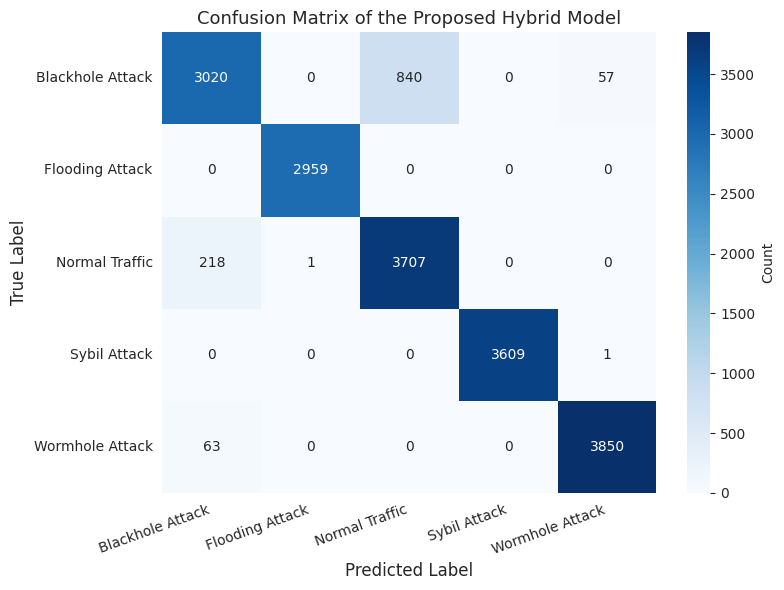

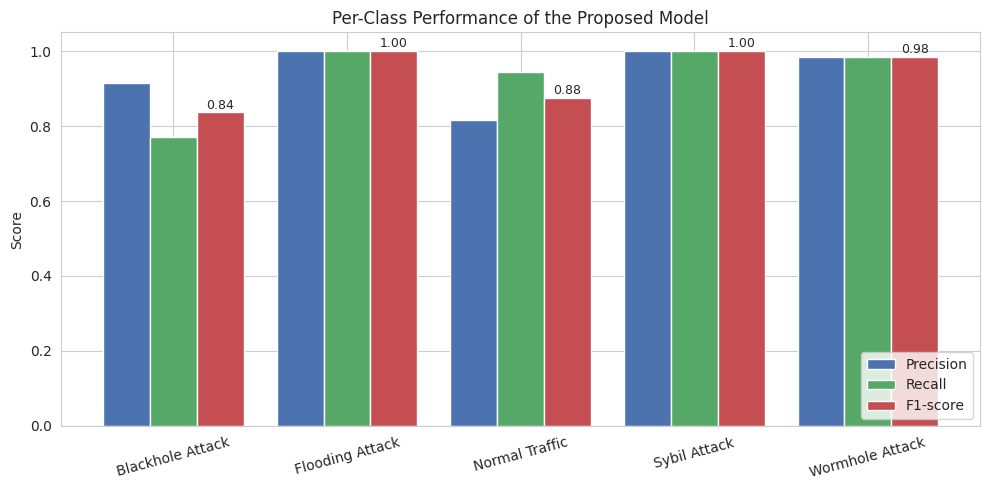

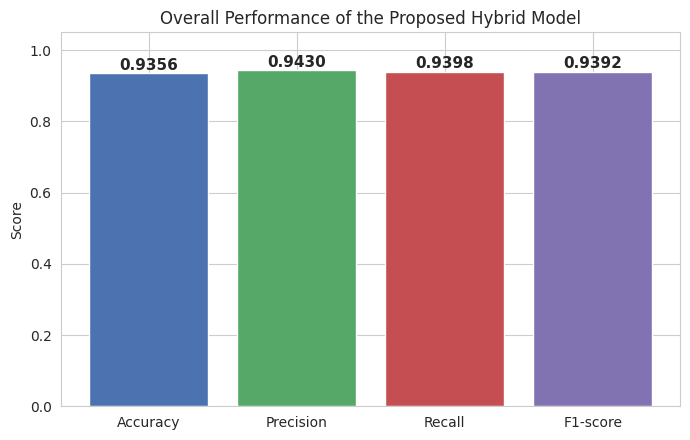

Saved: confusion_matrix.png, per_class_metrics.png, overall_metrics.png


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

sns.set_style("whitegrid")

# =====================
# 1) Confusion Matrix كصورة
# =====================
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_y.classes_, yticklabels=le_y.classes_,
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix of the Proposed Hybrid Model', fontsize=13)
plt.xticks(rotation=20, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

# =====================
# 2) Per-class F1 / Precision / Recall
# =====================
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
classes = le_y.classes_
x = np.arange(len(classes)); w = 0.27
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, p, w, label='Precision', color='#4C72B0')
ax.bar(x,     r, w, label='Recall',    color='#55A868')
ax.bar(x + w, f, w, label='F1-score',  color='#C44E52')
ax.set_xticks(x); ax.set_xticklabels(classes, rotation=15)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Per-Class Performance of the Proposed Model')
ax.legend(loc='lower right')
for i, v in enumerate(f):
    ax.text(i + w, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=200, bbox_inches='tight')
plt.show()

# =====================
# 3) Overall metrics
# =====================
metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-score': f1}
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(metrics.keys(), metrics.values(),
              color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Overall Performance of the Proposed Hybrid Model')
for b, v in zip(bars, metrics.values()):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.4f}',
            ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('overall_metrics.png', dpi=200, bbox_inches='tight')
plt.show()

print("Saved: confusion_matrix.png, per_class_metrics.png, overall_metrics.png")